# Limpieza y split del dataset SLICES

Este notebook limpia `semiconductores_listos_con_slices.csv` y crea particiones reproducibles:

- **train:** 80%
- **validation:** 10%
- **test:** 10%

La limpieza elimina valores nulos reales o escritos como texto (`NaN`, `None`, `null`, `N/A`), filas sin SLICES, infinitos numéricos, duplicados exactos y `material_id` repetidos. Las filas con el mismo `slices_string` se mantienen en la misma partición para evitar fuga de información.

In [1]:
from hashlib import sha256
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import GroupShuffleSplit

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 100)

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'semiconductores_listos_con_slices.csv').exists():
            return candidate
    raise FileNotFoundError('No se encontró el CSV fuente desde el directorio actual.')

PROJECT_ROOT = find_project_root(Path.cwd())
SOURCE_PATH = PROJECT_ROOT / 'data' / 'semiconductores_listos_con_slices.csv'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'splits'
CLEAN_PATH = OUTPUT_DIR / 'cleaned_data.csv'
TRAIN_PATH = OUTPUT_DIR / 'train.csv'
VAL_PATH = OUTPUT_DIR / 'val.csv'
TEST_PATH = OUTPUT_DIR / 'test.csv'
AUDIT_PATH = OUTPUT_DIR / 'split_audit.json'

TRAIN_FRACTION = 0.80
VAL_FRACTION = 0.10
TEST_FRACTION = 0.10
RANDOM_SEED = 42

assert np.isclose(TRAIN_FRACTION + VAL_FRACTION + TEST_FRACTION, 1.0)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Fuente: {SOURCE_PATH.relative_to(PROJECT_ROOT)}')
print(f'Salida: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}')

Fuente: data/semiconductores_listos_con_slices.csv
Salida: data/splits


## 1. Carga y auditoría inicial

Pandas detecta sus valores nulos habituales y además recibe una lista explícita de marcadores usados comúnmente en archivos CSV.

In [2]:
NA_LITERALS = [
    'None', 'none', 'NONE', 'null', 'NULL', 'Null',
    'NaN', 'nan', 'NAN', 'N/A', 'n/a', 'NA', '<NA>',
]
NULL_LITERALS_CASEFOLD = {value.casefold() for value in NA_LITERALS}

raw = pd.read_csv(
    SOURCE_PATH,
    keep_default_na=True,
    na_values=NA_LITERALS,
)

required_columns = {'material_id', 'slices_string'}
missing_columns = required_columns.difference(raw.columns)
if missing_columns:
    raise KeyError(f'Faltan columnas requeridas: {sorted(missing_columns)}')

initial_overview = pd.DataFrame({
    'métrica': [
        'filas', 'columnas', 'material_id únicos', 'SLICES únicos',
        'filas con algún nulo', 'duplicados exactos',
    ],
    'valor': [
        len(raw), raw.shape[1], raw['material_id'].nunique(dropna=True),
        raw['slices_string'].nunique(dropna=True), raw.isna().any(axis=1).sum(),
        raw.duplicated().sum(),
    ],
})
display(initial_overview)
display(raw.head(3))
display(raw.isna().sum().rename('nulos').to_frame())

,métrica,valor
0,filas,2036
1,columnas,15
2,material_id únicos,2036
3,SLICES únicos,2036
4,filas con algún nulo,0
5,duplicados exactos,0


,material_id,formula_pretty,nsites,nelements,volume,density,energy_per_atom,formation_energy_per_atom,energy_above_hull,is_stable,band_gap,is_magnetic,total_magnetization,structure,slices_string
0,mp-861884,AcGaTe2,4,3,127.622954,7.181229,-33.800317,-1.071641,0.237129,False,0.4910,False,0.000000,"{""@module"": ""pymatgen.core.structure"", ""@class"": ""Structure"", ""charge"": 0, ""lattice"": {""matrix"":...",Ac Ga Te Te 0 2 ooo 0 2 +oo 0 2 oo+ 0 2 o+o 0 3 -oo 0 3 oo- 0 3 o-o 0 3 ooo
1,mp-861460,AcInTe2,4,3,133.100510,7.448294,-36.677652,-1.165022,0.148074,False,0.3799,False,0.000000,"{""@module"": ""pymatgen.core.structure"", ""@class"": ""Structure"", ""charge"": 0, ""lattice"": {""matrix"":...",Ac In Te Te 0 2 oo+ 0 2 o+o 0 2 +oo 0 2 ooo 0 3 o-o 0 3 ooo 0 3 -oo 0 3 oo- 0 1 ++o 0 1 o++ 0 1 ...
2,mp-1215080,Ag12SBr,14,3,7332.202129,0.318507,-1.286220,1.563037,1.707333,False,0.3945,True,5.087515,"{""@module"": ""pymatgen.core.structure"", ""@class"": ""Structure"", ""charge"": 0, ""lattice"": {""matrix"":...",Ag Ag Ag Ag Ag Ag Ag Ag Ag Ag Ag Ag S Br 0 11 oo- 0 10 ooo 1 10 +oo 1 11 +o- 2 9 -oo 2 7 ooo 3 6...


,nulos
material_id,0
formula_pretty,0
nsites,0
nelements,0
volume,0
density,0
energy_per_atom,0
formation_energy_per_atom,0
energy_above_hull,0
is_stable,0


## 2. Limpieza

Los textos se recortan, los marcadores nulos se convierten a `pd.NA` y los espacios internos de SLICES se normalizan. Después se eliminan filas incompletas.

In [3]:
clean = raw.copy()

for column in clean.select_dtypes(include=['object', 'string']).columns:
    values = clean[column].astype('string').str.strip()
    invalid = values.str.casefold().isin(NULL_LITERALS_CASEFOLD) | values.eq('')
    clean[column] = values.mask(invalid, pd.NA)

# Convierte infinitos en nulos para que sean eliminados junto con las filas incompletas.
numeric_columns = clean.select_dtypes(include=[np.number]).columns
clean[numeric_columns] = clean[numeric_columns].replace([np.inf, -np.inf], np.nan)

# Un único espacio entre tokens hace reproducibles las comparaciones y los grupos.
clean['slices_string'] = clean['slices_string'].str.split().str.join(' ')
clean.loc[clean['slices_string'].eq(''), 'slices_string'] = pd.NA

rows_without_slices = int(clean['slices_string'].isna().sum())
rows_with_any_null = int(clean.isna().any(axis=1).sum())
clean = clean.dropna(axis=0, how='any').copy()

exact_duplicates = int(clean.duplicated().sum())
clean = clean.drop_duplicates().copy()
duplicate_material_ids = int(clean.duplicated(subset=['material_id']).sum())
clean = clean.drop_duplicates(subset=['material_id'], keep='first').reset_index(drop=True)

if clean.empty:
    raise ValueError('La limpieza eliminó todas las filas.')
if clean.isna().any().any():
    raise AssertionError('La tabla limpia todavía contiene valores nulos.')
if clean['slices_string'].str.strip().eq('').any():
    raise AssertionError('La tabla limpia todavía contiene SLICES vacíos.')
if clean['material_id'].duplicated().any():
    raise AssertionError('La tabla limpia todavía contiene material_id repetidos.')

cleaning_audit = pd.DataFrame({
    'métrica': [
        'filas originales', 'filas sin SLICES', 'filas con algún nulo',
        'duplicados exactos', 'material_id duplicados', 'filas conservadas',
        'filas eliminadas',
    ],
    'valor': [
        len(raw), rows_without_slices, rows_with_any_null, exact_duplicates,
        duplicate_material_ids, len(clean), len(raw) - len(clean),
    ],
})
display(cleaning_audit)
display(clean.head(3))

,métrica,valor
0,filas originales,2036
1,filas sin SLICES,0
2,filas con algún nulo,0
3,duplicados exactos,0
4,material_id duplicados,0
5,filas conservadas,2036
6,filas eliminadas,0


,material_id,formula_pretty,nsites,nelements,volume,density,energy_per_atom,formation_energy_per_atom,energy_above_hull,is_stable,band_gap,is_magnetic,total_magnetization,structure,slices_string
0,mp-861884,AcGaTe2,4,3,127.622954,7.181229,-33.800317,-1.071641,0.237129,False,0.4910,False,0.000000,"{""@module"": ""pymatgen.core.structure"", ""@class"": ""Structure"", ""charge"": 0, ""lattice"": {""matrix"":...",Ac Ga Te Te 0 2 ooo 0 2 +oo 0 2 oo+ 0 2 o+o 0 3 -oo 0 3 oo- 0 3 o-o 0 3 ooo
1,mp-861460,AcInTe2,4,3,133.100510,7.448294,-36.677652,-1.165022,0.148074,False,0.3799,False,0.000000,"{""@module"": ""pymatgen.core.structure"", ""@class"": ""Structure"", ""charge"": 0, ""lattice"": {""matrix"":...",Ac In Te Te 0 2 oo+ 0 2 o+o 0 2 +oo 0 2 ooo 0 3 o-o 0 3 ooo 0 3 -oo 0 3 oo- 0 1 ++o 0 1 o++ 0 1 ...
2,mp-1215080,Ag12SBr,14,3,7332.202129,0.318507,-1.286220,1.563037,1.707333,False,0.3945,True,5.087515,"{""@module"": ""pymatgen.core.structure"", ""@class"": ""Structure"", ""charge"": 0, ""lattice"": {""matrix"":...",Ag Ag Ag Ag Ag Ag Ag Ag Ag Ag Ag Ag S Br 0 11 oo- 0 10 ooo 1 10 +oo 1 11 +o- 2 9 -oo 2 7 ooo 3 6...


## 3. Split 80/10/10 sin fuga de SLICES

Se usa `GroupShuffleSplit` con `slices_string` como grupo. Primero se separa 80% para entrenamiento; el 20% restante se divide por la mitad para validación y prueba. La semilla fija permite reproducir exactamente el resultado.

In [4]:
groups = clean['slices_string']
first_split = GroupShuffleSplit(
    n_splits=1, train_size=TRAIN_FRACTION, random_state=RANDOM_SEED
)
train_idx, holdout_idx = next(first_split.split(clean, groups=groups))

train = clean.iloc[train_idx].copy()
holdout = clean.iloc[holdout_idx].copy()

second_split = GroupShuffleSplit(
    n_splits=1, train_size=VAL_FRACTION / (VAL_FRACTION + TEST_FRACTION),
    random_state=RANDOM_SEED + 1,
)
val_relative_idx, test_relative_idx = next(
    second_split.split(holdout, groups=holdout['slices_string'])
)
val = holdout.iloc[val_relative_idx].copy()
test = holdout.iloc[test_relative_idx].copy()

# Mezcla el orden interno sin cambiar la pertenencia a cada split.
train = train.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
val = val.sample(frac=1, random_state=RANDOM_SEED + 1).reset_index(drop=True)
test = test.sample(frac=1, random_state=RANDOM_SEED + 2).reset_index(drop=True)

splits = {'train': train, 'val': val, 'test': test}

# Comprobaciones de integridad y ausencia de fuga.
assert sum(len(frame) for frame in splits.values()) == len(clean)
assert all(not frame.isna().any().any() for frame in splits.values())
for left_name, right_name in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    left, right = splits[left_name], splits[right_name]
    assert set(left['material_id']).isdisjoint(right['material_id'])
    assert set(left['slices_string']).isdisjoint(right['slices_string'])

split_summary = pd.DataFrame([
    {
        'split': name,
        'filas': len(frame),
        'porcentaje': 100 * len(frame) / len(clean),
        'material_id_únicos': frame['material_id'].nunique(),
        'slices_únicos': frame['slices_string'].nunique(),
        'nulos': int(frame.isna().sum().sum()),
    }
    for name, frame in splits.items()
])
display(split_summary)

,split,filas,porcentaje,material_id_únicos,slices_únicos,nulos
0,train,1628,79.960707,1628,1628,0
1,val,204,10.019646,204,204,0
2,test,204,10.019646,204,204,0


## 4. Comprobar distribución de propiedades

El split es aleatorio por grupos, no estratificado. Esta tabla permite detectar desviaciones grandes entre particiones antes de entrenar.

,split,filas,energy_per_atom_media,formation_energy_per_atom_media,energy_above_hull_media,band_gap_media,density_media,volume_media,is_stable_proporción_true,is_magnetic_proporción_true
0,train,1628,-9.169995,-1.340275,0.268721,0.398194,4.720661,298.373703,0.164005,0.542998
1,val,204,-10.306861,-1.206147,0.302895,0.401540,4.650012,375.045891,0.225490,0.490196
2,test,204,-9.106964,-1.298230,0.292181,0.403133,4.664220,304.228664,0.220588,0.524510


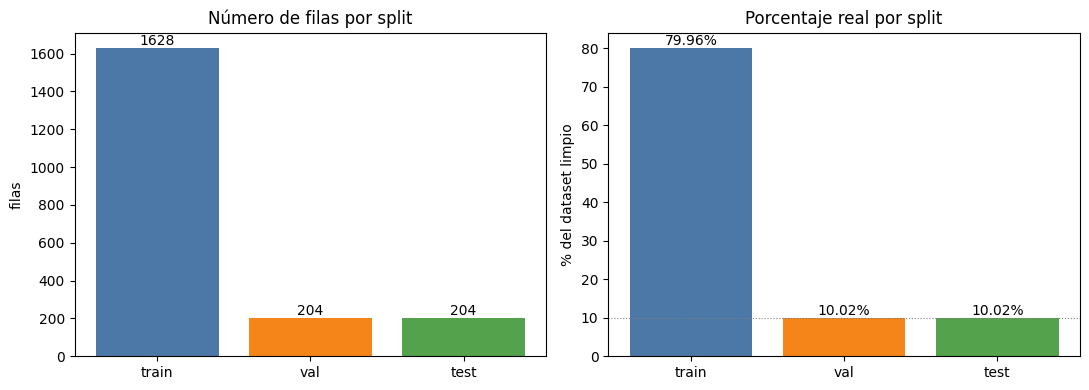

In [5]:
numeric_metrics = [
    column for column in [
        'energy_per_atom', 'formation_energy_per_atom', 'energy_above_hull',
        'band_gap', 'density', 'volume',
    ] if column in clean.columns
]
boolean_metrics = [
    column for column in ['is_stable', 'is_magnetic'] if column in clean.columns
]

distribution_rows = []
for name, frame in splits.items():
    row = {'split': name, 'filas': len(frame)}
    row.update({f'{column}_media': frame[column].mean() for column in numeric_metrics})
    row.update({f'{column}_proporción_true': frame[column].astype(bool).mean() for column in boolean_metrics})
    distribution_rows.append(row)

distribution_summary = pd.DataFrame(distribution_rows)
display(distribution_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(split_summary['split'], split_summary['filas'], color=['#4C78A8', '#F58518', '#54A24B'])
axes[0].set(title='Número de filas por split', ylabel='filas')
for index, value in enumerate(split_summary['filas']):
    axes[0].text(index, value, str(value), ha='center', va='bottom')

axes[1].bar(split_summary['split'], split_summary['porcentaje'], color=['#4C78A8', '#F58518', '#54A24B'])
axes[1].axhline(10, color='gray', linewidth=0.8, linestyle=':')
axes[1].set(title='Porcentaje real por split', ylabel='% del dataset limpio')
for index, value in enumerate(split_summary['porcentaje']):
    axes[1].text(index, value, f'{value:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 5. Guardar los datos y la auditoría

Además de los tres splits se conserva el dataset limpio y un JSON con la configuración, conteos y huella SHA-256 del CSV fuente.

In [6]:
clean.to_csv(CLEAN_PATH, index=False)
train.to_csv(TRAIN_PATH, index=False)
val.to_csv(VAL_PATH, index=False)
test.to_csv(TEST_PATH, index=False)

source_sha256 = sha256(SOURCE_PATH.read_bytes()).hexdigest()
audit = {
    'source': str(SOURCE_PATH.relative_to(PROJECT_ROOT)),
    'source_sha256': source_sha256,
    'random_seed': RANDOM_SEED,
    'group_column': 'slices_string',
    'requested_fractions': {
        'train': TRAIN_FRACTION, 'val': VAL_FRACTION, 'test': TEST_FRACTION,
    },
    'cleaning': {
        'original_rows': int(len(raw)),
        'rows_without_slices': rows_without_slices,
        'rows_with_any_null': rows_with_any_null,
        'exact_duplicates': exact_duplicates,
        'duplicate_material_ids': duplicate_material_ids,
        'clean_rows': int(len(clean)),
        'removed_rows': int(len(raw) - len(clean)),
    },
    'splits': {
        name: {
            'rows': int(len(frame)),
            'fraction': float(len(frame) / len(clean)),
            'unique_slices': int(frame['slices_string'].nunique()),
        }
        for name, frame in splits.items()
    },
}
AUDIT_PATH.write_text(json.dumps(audit, indent=2, ensure_ascii=False) + '\n', encoding='utf-8')

for path, frame in [
    (CLEAN_PATH, clean), (TRAIN_PATH, train), (VAL_PATH, val), (TEST_PATH, test),
]:
    print(f'{path.relative_to(PROJECT_ROOT)}: {len(frame):,} filas')
print(f'{AUDIT_PATH.relative_to(PROJECT_ROOT)}')

data/splits/cleaned_data.csv: 2,036 filas
data/splits/train.csv: 1,628 filas
data/splits/val.csv: 204 filas
data/splits/test.csv: 204 filas
data/splits/split_audit.json


## Resultado

Los archivos de `data/splits/` están listos para entrenamiento, selección de hiperparámetros y evaluación final. `test.csv` debe permanecer aislado hasta elegir definitivamente el modelo.